# Code

## Configuration & General

In [ ]:
!pip install torchmetrics -q

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import wandb
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchmetrics.regression import MeanSquaredError, MeanAbsoluteError, R2Score
from google.colab import drive

# --- CONFIGURATION & GLOBALS ---
drive.mount('content/')
wandb.login()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.style.use("ggplot")


BASE_DIR = "content/MyDrive/Colab Notebooks/GP Datasets/"
MAIN_CSV_FILE = "fteng_main_latest.csv"
MAIN_CSV_PATH = os.path.join(BASE_DIR, MAIN_CSV_FILE)

Drive already mounted at content/; to attempt to forcibly remount, call drive.mount("content/", force_remount=True).


In [ ]:
countries_ids = {'United States': 0, 'India': 1, 'China': 2, 'Brazil': 3, 'Nigeria': 4, 'Germany': 5, 'Japan': 6, 'United Kingdom': 7, 'France': 8, 'Australia': 9, 'Kenya': 10, 'Mexico': 11, 'Indonesia': 12, 'Pakistan': 13, 'Bangladesh': 14, 'Egypt': 15, 'South Africa': 16, 'Canada': 17, 'Spain': 18, 'Italy': 19, 'Thailand': 20, 'Philippines': 21, 'Vietnam': 22, 'Argentina': 23, 'Colombia': 24}
targets = ['respiratory_disease_rate', 'cardio_mortality_rate', 'vector_disease_risk_score', 'waterborne_disease_incidents', 'heat_related_admissions']

In [ ]:
data_df = pd.read_csv(MAIN_CSV_PATH)

data_df.shape

(14100, 117)

## Checkpoint Saver

In [ ]:
import pickle
import copy
import glob

class CheckpointSaver:
    def __init__(self, dirpath="./checkpoints", decreasing=True, save_model=True):
        self.dirpath = dirpath
        os.makedirs(dirpath, exist_ok=True)
        self.decreasing = decreasing
        self.save_model = save_model

        # Track the best metric
        self.best_metric = float('inf') if decreasing else float('-inf')

        # We store the best checkpoint in RAM (CPU).
        self.best_checkpoint_payload = None
        self.best_epoch = -1
        self.best_fold = -1
        self.run_id = None

    def update(self, model, fold, epoch, metric, run_id):
        """Checks if current model is best. If yes, caches it to RAM."""

        is_best = (metric < self.best_metric) if self.decreasing else (metric > self.best_metric)

        if not is_best:
            return False

        self.best_metric = metric
        self.best_epoch = epoch
        self.best_fold = fold
        self.run_id = run_id

        self.best_checkpoint_payload = {
            "epoch": epoch,
            "metric": metric,
            "model_state_dict": {k: v.cpu().clone() for k, v in model.state_dict().items()}
        }

        print(f"-> New Best Model found at Epoch {epoch} | Metric={metric:.4f}")
        return True

    @staticmethod
    def load_artifact_model(run_id, model_instance, project="sehetna/sehetna-main"):
        api = wandb.Api()
        artifact_path = f"{project}/{run_id}"

        try:
            artifact = api.artifact(artifact_path)
        except Exception as e:
            print(f"Error: Could not find artifact at {artifact_path}: {e}")
            return None

        print("-> Downloading artifact...")
        artifact_dir = artifact.download()

        pkl_files = glob.glob(os.path.join(artifact_dir, "*.pkl"))
        if not pkl_files:
            print("Error: No .pkl file found in the artifact.")
            return None

        model_pkl = pkl_files[0]
        print(f"-> Found checkpoint: {os.path.basename(model_pkl)}")

        with open(model_pkl, "rb") as f:
            checkpoint = pickle.load(f)

        state_dict = checkpoint.get("model_state_dict", checkpoint)

        # CRITICAL FIX: Remove _orig_mod. prefix if present
        cleaned_state_dict = {}
        has_orig_mod = False

        for key, value in state_dict.items():
            if key.startswith('_orig_mod.'):
                new_key = key.replace('_orig_mod.', '')
                cleaned_state_dict[new_key] = value
                has_orig_mod = True
            else:
                cleaned_state_dict[key] = value

        if has_orig_mod:
            print("-> Detected torch.compile() prefix (_orig_mod.), stripping it...")

        try:
            model_instance.load_state_dict(cleaned_state_dict)
            print("-> Weights successfully loaded into model.")
        except RuntimeError as e:
            print(f"-> Shape Mismatch! Are you loading Transformer weights into an MLP?")
            print(f"Error: {e}")

            # Debug info
            print("\nExpected keys (first 5):")
            for i, key in enumerate(list(model_instance.state_dict().keys())[:5]):
                print(f"  {key}")

            print("\nCheckpoint keys (first 5):")
            for i, key in enumerate(list(cleaned_state_dict.keys())[:5]):
                print(f"  {key}")

            return None

        return model_instance

    def __call__(self):
        """Call this ONCE at the very end of training."""
        if not self.save_model or self.best_checkpoint_payload is None:
            print("No model to save (or save_model=False).")
            return

        name = f"{self.run_id}-fold-{self.best_fold}-best-epoch-{self.best_epoch}.pkl"
        best_pkl = os.path.join(self.dirpath, name)

        description = f"Best Model: Fold {self.best_fold} | Epoch {self.best_epoch} | Metric={self.best_metric:.4f}"
        print(f"-> Saving to Disk: {name} ...")

        # Save to Disk
        with open(best_pkl, "wb") as f:
            pickle.dump(self.best_checkpoint_payload, f)

        # Upload to WandB
        if wandb.run is not None:
            print(f"-> Uploading to WandB...")
            artifact = wandb.Artifact(name=f"model-{self.run_id}", type="model", description=description)
            artifact.add_file(best_pkl)
            wandb.log_artifact(artifact)
            print("-> Upload Complete.")

Saver = CheckpointSaver()

## Feature Selection

In [ ]:
features = [
    # 'onehot_encoder__country_code_ARG', 'onehot_encoder__country_code_AUS', 'onehot_encoder__country_code_BGD', 'onehot_encoder__country_code_BRA', 'onehot_encoder__country_code_CAN', 'onehot_encoder__country_code_CHN', 'onehot_encoder__country_code_COL', 'onehot_encoder__country_code_DEU', 'onehot_encoder__country_code_EGY', 'onehot_encoder__country_code_ESP', 'onehot_encoder__country_code_FRA', 'onehot_encoder__country_code_GBR', 'onehot_encoder__country_code_IDN', 'onehot_encoder__country_code_IND', 'onehot_encoder__country_code_ITA', 'onehot_encoder__country_code_JPN', 'onehot_encoder__country_code_KEN', 'onehot_encoder__country_code_MEX', 'onehot_encoder__country_code_NGA', 'onehot_encoder__country_code_PAK', 'onehot_encoder__country_code_PHL', 'onehot_encoder__country_code_THA', 'onehot_encoder__country_code_USA', 'onehot_encoder__country_code_VNM', 'onehot_encoder__country_code_ZAF', 'onehot_encoder__country_name_Argentina', 'onehot_encoder__country_name_Australia', 'onehot_encoder__country_name_Bangladesh', 'onehot_encoder__country_name_Brazil', 'onehot_encoder__country_name_Canada', 'onehot_encoder__country_name_China', 'onehot_encoder__country_name_Colombia', 'onehot_encoder__country_name_Egypt', 'onehot_encoder__country_name_France', 'onehot_encoder__country_name_Germany', 'onehot_encoder__country_name_India', 'onehot_encoder__country_name_Indonesia', 'onehot_encoder__country_name_Italy', 'onehot_encoder__country_name_Japan', 'onehot_encoder__country_name_Kenya', 'onehot_encoder__country_name_Mexico', 'onehot_encoder__country_name_Nigeria', 'onehot_encoder__country_name_Pakistan', 'onehot_encoder__country_name_Philippines', 'onehot_encoder__country_name_South Africa', 'onehot_encoder__country_name_Spain', 'onehot_encoder__country_name_Thailand', 'onehot_encoder__country_name_United Kingdom', 'onehot_encoder__country_name_United States', 'onehot_encoder__country_name_Vietnam', 'onehot_encoder__region_Africa', 'onehot_encoder__region_East Asia', 'onehot_encoder__region_Europe', 'onehot_encoder__region_North America', 'onehot_encoder__region_Oceania', 'onehot_encoder__region_South America', 'onehot_encoder__region_South Asia', 'onehot_encoder__region_Southeast Asia',
    'ordinal_encoder__income_level',
    'imputer_scaled__uhs_service_coverage_index',
    'capper_scaled__healthcare_access_index',
    'capper_scaled__mental_health_index',
    'capper_scaled__food_security_index',
    'capper_scaled__pm25_ugm3',
    'capper_scaled__air_quality_index',
    'capper_scaled__temperature_celsius',
    'capper_scaled__temp_anomaly_celsius',
    'capper_scaled__precipitation_mm',
    'capper_scaled__pm25_ugm3_lag_1w',
    'capper_scaled__pm25_ugm3_lag_2w',
    'capper_scaled__pm25_ugm3_lag_4w',
    'capper_scaled__temp_lag_1w',
    'capper_scaled__temp_lag_2w',
    'capper_scaled__temp_2w_avg',
    'capper_scaled__temp_2w_volatility',
    'capper_scaled__temp_4w_volatility',
    'capper_scaled__log_temp_squared',
    'capper_scaled__temp_change_rate',
    'capper_scaled__pm25_change_rate',
    'capper_scaled__precip_change_rate',
    'capper_scaled__spatial_lag_pm25',
    'capper_scaled__spatial_lag_temp',
    'capper_scaled__spatial_lag_temp_anomaly',
    'capper_scaled__pm25_temp_interaction',
    'capper_scaled__temp_precip_interaction',
    'capper_scaled__pm25_precip_interaction',
    'capper_scaled__extreme_weather_score',
    'capper_scaled__pollution_vulnerability',
    'num_scaler__population_millions',
    # 'num_scaler__aqi_pm',
    'num_scaler__gdp_per_capita_usd',
    # 'num_scaler__latitude',
    # 'num_scaler__longitude',
    # 'num_scaler__day_of_week',
    'num_scaler__quarter',
    # 'num_scaler__distance_to_equator',
    # 'pass_through__record_id',
    # 'pass_through__country_id',
    # 'pass_through__heat_wave_days',
    # 'pass_through__drought_indicator',
    # 'pass_through__flood_indicator',
    # 'pass_through__extreme_weather_events',
    # 'pass_through__year',
    # 'pass_through__date',
    'pass_through__month_sin',
    'pass_through__month_cos',
    'pass_through__week_sin',
    'pass_through__week_cos',
    'pass_through__is_northern',
    'pass_through__is_tropical',
    'pass_through__log_food_security_index',
]


## Data Preparation Helpers

### K-Fold Helpers

For *`spatiotemporal_kfold`* They won't ask:

> Can your model **predict next week in 2019**?

For *`temporal_leave_years_out`* They'll ask:

> Can this model still **work after climate patterns** or policies change?

Leaving out **1-3 year(s)** is the solution.

In [ ]:
# @title
from torch.utils.data import Subset, DataLoader

def spatiotemporal_kfold(dataset, k=5):
    years = sorted(set(s["year"] for s in dataset.samples))
    max_folds = len(years) - 2
    k = min(k, max_folds)

    folds = []

    for i in range(k):
        train_end = years[i]
        val_year = years[i + 1]
        test_year = years[i + 2]

        train_idx, val_idx, test_idx = [], [], []

        for idx, s in enumerate(dataset.samples):
            if s["year"] <= train_end:
                train_idx.append(idx)
            elif s["year"] == val_year:
                val_idx.append(idx)
            elif s["year"] == test_year:
                test_idx.append(idx)

        if len(train_idx) == 0 or len(val_idx) == 0 or len(test_idx) == 0:
            continue  # safety

        folds.append({
            "train_idx": train_idx,
            "val_idx": val_idx,
            "test_idx": test_idx,
            "train_years": f"{years[0]}-{train_end}",
            "val_year": val_year,
            "test_year": test_year
        })

    return folds

In [ ]:
def temporal_leave_years_out(dataset, val_years=2, test_years=3):
    years = list(range(2015, 2026))

    assert len(years) >= val_years + test_years + 1, f"Not enough unique years: {len(years)}"

    train_end_year = years[-(val_years + test_years + 1)]
    val_year_set = set(years[-(val_years + test_years):-test_years])
    test_year_set = set(years[-test_years:])

    train_idx, val_idx, test_idx = [], [], []

    for idx, s in enumerate(dataset.samples):
        y = s["year"]

        if y <= train_end_year:
            train_idx.append(idx)
        elif y in val_year_set:
            val_idx.append(idx)
        elif y in test_year_set:
            test_idx.append(idx)

    return {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
        "train_years": f"{years[0]}-{train_end_year}",
        "val_years": sorted(val_year_set),
        "test_years": sorted(test_year_set),
    }

### Build K-Fold Dataloaders

In [ ]:
def build_kfold_dataloaders(df, seq_len, batch_size=32, val_years=2, test_years=3):
    full_dataset = ClimateHealthDataset(df, seq_len)

    folds = [temporal_leave_years_out(full_dataset, val_years, test_years)]
    results = []

    for f in folds:
        train_ds = Subset(full_dataset, f["train_idx"])
        val_ds   = Subset(full_dataset, f["val_idx"])
        test_ds  = Subset(full_dataset, f["test_idx"])

        results.append({
            "train_loader": DataLoader(train_ds, batch_size=batch_size, shuffle=True),
            "val_loader": DataLoader(val_ds, batch_size=batch_size),
            "test_loader": DataLoader(test_ds, batch_size=batch_size),

            "train_years": f["train_years"],
            "val_years": f["val_years"],
            "test_years": f["test_years"]
        })

    return results

## Datasets & Model

### 2 Different Approaches
#### Sliding Window per Country (No Embeddings)
**Prototyping** & No country id.
```py
X: (N, W, F)
y: (N, K)
```

---

### Sliding Window + Country Embeddings
**Cross-country** generalization & shared learning.

```py
time_series : (N, W, F)
country_id  : (N,)
target      : (N, K)
```

In [ ]:
class ClimateHealthDataset(Dataset):
    def __init__(self, df, seq_len):
        self.seq_len = seq_len
        self.samples = []

        for c_id, country_df in df.groupby("pass_through__country_id"):
            X = country_df[features].values.astype("float32")
            y = country_df[targets].values.astype("float32")
            years = country_df["pass_through__year"].values

            for t in range(seq_len, len(country_df)):
                self.samples.append({"X": X[t - seq_len : t], "y": y[t], "c_id": c_id, "year": years[t]})

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        X_num = torch.from_numpy(sample["X"]).float()
        country_id = torch.tensor(sample["c_id"], dtype=torch.long)
        y = torch.from_numpy(sample["y"]).float()

        return X_num, country_id, y

### Model

In [ ]:
# country_id, seq_len, e_dim = 12, 2, 8
# country_embed = nn.Embedding(num_embeddings=len(countries_ids), embedding_dim=e_dim)
# lstm = nn.LSTM(input_size=len(features) + e_dim, hidden_size=128, num_layers=2, dropout=0.2, batch_first=True)

# country_vec = country_embed(torch.tensor(country_id, dtype=torch.long))
# country_seq = country_vec.unsqueeze(1).repeat(1, seq_len, 1)
# country_seq

In [ ]:
class LSTMCountryEmbeddings(nn.Module):
    def __init__(self, config, output_size=None):
        super().__init__()
        self.country_embed = nn.Embedding(num_embeddings=config.num_embeddings, embedding_dim=config.embed_dim)

        self.lstm = nn.LSTM(
            input_size=len(features) + config.embed_dim,
            hidden_size=config.lstm__hidden_size,
            num_layers=config.lstm__num_layers,
            dropout=config.lstm__dropout if config.lstm__num_layers > 1 else 0,
            batch_first=True
        )
        afs = {"relu": nn.ReLU(), "gelu": nn.GELU(), "leakyrelu": nn.LeakyReLU(), "silu": nn.SiLU()}
        self.first_act = afs.get(config.first_act)
        self.second_act = afs.get(config.second_act)

        self.head = nn.Sequential(
            nn.Linear(config.lstm__hidden_size, config.linear__first_hidden_size),
            self.first_act,
            nn.Dropout(config.first_dropout),
            nn.Linear(config.linear__first_hidden_size, config.linear__second_hidden_size),
            self.second_act,
            nn.Dropout(config.second_dropout),
            nn.Linear(config.linear__second_hidden_size, output_size)
        )

    def forward(self, x_num, country_id):
        batch_size, seq_len, _ = x_num.shape
        country_vec = self.country_embed(country_id)
        country_seq = country_vec.unsqueeze(1).repeat(1, seq_len, 1) # Repeat across time
        x = torch.cat([x_num, country_seq], dim=-1)
        # _, (h_n, _) = self.lstm(x)
        # h_last = h_n[-1] # Take last hidden state

        out, _ = self.lstm(x)
        h_last = out.mean(dim=1)
        return self.head(h_last)

## Training & Validation Loops

In [ ]:
from torch.amp import autocast, GradScaler

def train_one_epoch(model: LSTMCountryEmbeddings, dataloader: ClimateHealthDataset, optimizer, criterion):
    model.train()
    epoch_losses = []

    scaler = GradScaler()

    for i, batch in enumerate(dataloader):
        X_num, country_id, y = batch
        X_num, country_id, y = X_num.to(device), country_id.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device.type):
            preds = model.forward(X_num, country_id)
            loss = criterion(preds, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        epoch_losses.append(loss.item())

    return float(np.mean(epoch_losses))

In [ ]:
@torch.no_grad()
def validate_one_epoch(model, dataloader, criterion):
    model.eval()

    mse_metric = MeanSquaredError().to(device)
    mae_metric = MeanAbsoluteError().to(device)
    r2_metric = R2Score().to(device)

    mse_metric.reset()
    mae_metric.reset()
    r2_metric.reset()

    total_loss = 0.0
    total_samples = 0

    for X_num, country_id, y in dataloader:
        X_num, country_id, y = X_num.to(device), country_id.to(device), y.to(device)

        with torch.autocast(device.type):
            preds = model(X_num, country_id)
            loss = criterion(preds, y)

        batch_size = y.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        mse_metric.update(preds, y)
        mae_metric.update(preds, y)
        r2_metric.update(preds, y)

    mse = mse_metric.compute().item()
    mae = mae_metric.compute().item()
    rmse = np.sqrt(mse)
    r2 = r2_metric.compute().item()
    avg_loss = total_loss / total_samples

    return avg_loss, mae, rmse, r2

In [ ]:
def train(model, fold, train_loader, val_loader, optimizer, criterion, run_id, config):
    for epoch in range(1, config.e + 1):
        t_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        v_loss, mae, rmse, r2 = validate_one_epoch(model, val_loader, criterion)

        wandb.log({"train/loss": t_loss, "val/loss_mse": v_loss, "val/rmse": rmse, "val/mae": mae, "val/r2": r2, "epoch": epoch, "fold": fold})
        print(f"Fold {fold} | Epoch {epoch} => Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val RMSE: {rmse:.4f} | Val MAE: {mae:.4f} | Val R2: {r2:.4f}")

        Saver.update(model, fold, epoch, mae, run_id)

    Saver()

## Start Training

In [ ]:
def start(config=None):
    with wandb.init(config=config) as run:
        config = wandb.config
        folds = build_kfold_dataloaders(data_df, config.seq_len, config.batch_size, config.val_years, config.test_years)

        for i, fold in enumerate(folds, start=1):
            model = LSTMCountryEmbeddings(config, output_size=len(targets)).to(device)
            criterion = nn.MSELoss()
            optimizers = {"adamw": torch.optim.AdamW, "adam": torch.optim.Adam}
            OPT = optimizers.get(config.opt, torch.optim.SGD)
            optimizer = OPT(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)

            print(f"\n--- Fold {i} | Train: {fold['train_years']} | Val: {fold['val_years']} ---")
            train(model, i, fold["train_loader"], fold["val_loader"], optimizer, criterion, run.id, config)

## Sweep Configuration

In [ ]:
# ------- Versioning -------
# v0 Major: changing and introducing new layers, defining new splitting technique, or adjusting features.
# v0.0 minor: adding/removing new sweep configuration parameter keys.
# v0.0.0 patch: updating values of sweep configuration parameters.

sweep_configuration = {
    "name": "climate-health-lstm-v1.0.0",
    "method": "bayes",
    "metric": { "name": "val/mae", "goal": "minimize" },
    "parameters": {

        # MODEL ARCHITECTURE
        "num_embeddings": {"value": len(countries_ids)},
        "embed_dim": { "values": [8, 16, 24, 32]  },
        "lstm__hidden_size": { "distribution": "int_uniform", "min": 64, "max": 512 },
        "lstm__num_layers": { "values": [1, 2, 3, 4] },
        "lstm__dropout": { "distribution": "uniform", "min": 0.1, "max": 0.5 },

        "first_dropout": { "distribution": "uniform", "min": 0.3, "max": 0.4 },
        "second_dropout": { "distribution": "uniform", "min": 0.0, "max": 0.15 },
        "linear__first_hidden_size": { "values": [128, 256, 512] },
        "linear__second_hidden_size": { "values": [32, 64, 128] },

        # ACTIVATION FUNCTIONS
        "first_act": { "values": ["relu", "gelu", "silu"] },
        "second_act": { "values": ["relu", "gelu", "silu"] },

        # OPTIMIZATION
        "lr": { "distribution": "log_uniform_values", "min": 1e-4, "max": 1e-2 },
        "weight_decay": { "distribution": "log_uniform_values", "min": 1e-5, "max": 0.1 },
        "batch_size": {"value": 128},
        "opt": { "values": ["adamw", "adam"] },

        # DATA PREPARATION
        "seq_len": { "values": [12, 24] },

        "val_years": { "value": 2 },
        "test_years": { "value": 3 },
        "e": { "value": 32 } # 2, 8, 16
    }
}

desc = f"""This sweep aims to optimize the LSTMCountryEmbeddings model for climate-health predictions.

The model incorporates:
*   **Country Embeddings**: Learns country-specific representations.
*   **LSTM Layer**: Processes sequential climate and health data over time.
*   **Sequential Head**: A series of dense layers for final target prediction.

The primary objective is to **minimize Mean Absolute Error (MAE)** on the validation set.

Key parameters being tuned include:
```py
{sweep_configuration['parameters']}
```

## Change Log
### V1.0.0. NEW SPLITTING TECHNIQUE
* temporal_leave_years_out (Leaving out **1-3 year(s)**): another approach was introduced to split the data instead of spatiotemporal_kfold

"""

sweep_configuration["description"] = desc

## Initialize Sweep

In [ ]:
wandb_project = "sehetna-main"
sweep_id = wandb.sweep(sweep=sweep_configuration, project=wandb_project)
wandb.agent(sweep_id, function=start, count=5)

Create sweep with ID: 0c9wytyj
Sweep URL: https://wandb.ai/sehetna/sehetna-main/sweeps/0c9wytyj


wandb: Agent Starting Run: qwjfa35w with config:
wandb: 	batch_size: 128
wandb: 	e: 32
wandb: 	embed_dim: 24
wandb: 	first_act: gelu
wandb: 	first_dropout: 0.3849107816224503
wandb: 	linear__first_hidden_size: 512
wandb: 	linear__second_hidden_size: 64
wandb: 	lr: 0.002149083394243596
wandb: 	lstm__dropout: 0.24357408198807384
wandb: 	lstm__hidden_size: 238
wandb: 	lstm__num_layers: 2
wandb: 	num_embeddings: 25
wandb: 	opt: adam
wandb: 	second_act: relu
wandb: 	second_dropout: 0.13826341566636707
wandb: 	seq_len: 12
wandb: 	test_years: 3
wandb: 	val_years: 2
wandb: 	weight_decay: 0.01147458967997248



--- Fold 1 | Train: 2015-2020 | Val: [2021, 2022] ---
Fold 1 | Epoch 1 => Train Loss: 0.8765 | Val Loss: 0.8532 | Val RMSE: 0.9237 | Val MAE: 0.7008 | Val R2: 0.1601
-> New Best Model found at Epoch 1 | Metric=0.7008
Fold 1 | Epoch 2 => Train Loss: 0.7985 | Val Loss: 0.8159 | Val RMSE: 0.9033 | Val MAE: 0.6817 | Val R2: 0.1979
-> New Best Model found at Epoch 2 | Metric=0.6817
Fold 1 | Epoch 3 => Train Loss: 0.7678 | Val Loss: 0.7764 | Val RMSE: 0.8811 | Val MAE: 0.6606 | Val R2: 0.2382
-> New Best Model found at Epoch 3 | Metric=0.6606
Fold 1 | Epoch 4 => Train Loss: 0.7527 | Val Loss: 0.7676 | Val RMSE: 0.8761 | Val MAE: 0.6551 | Val R2: 0.2472
-> New Best Model found at Epoch 4 | Metric=0.6551
Fold 1 | Epoch 5 => Train Loss: 0.7437 | Val Loss: 0.7580 | Val RMSE: 0.8706 | Val MAE: 0.6507 | Val R2: 0.2564
-> New Best Model found at Epoch 5 | Metric=0.6507
Fold 1 | Epoch 6 => Train Loss: 0.7342 | Val Loss: 0.7492 | Val RMSE: 0.8656 | Val MAE: 0.6515 | Val R2: 0.2650
Fold 1 | Epoch 7 =

epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇███
fold,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val/loss_mse,█▆▅▄▄▄▃▄▃▃▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▂▂
val/mae,█▇▅▅▄▄▄▄▃▄▄▄▃▃▃▃▃▃▂▂▂▃▁▁▁▂▁▂▁▂▂▁
val/r2,▁▃▄▅▅▆▆▅▆▆▆▆▆▆▆▆▆▆▇▇▇▆▇▇▇▇████▇▇
val/rmse,█▆▅▄▄▄▄▄▃▃▄▃▃▃▃▃▃▃▂▂▂▃▂▂▂▂▁▁▁▁▂▂
epoch,32
fold,1
train/loss,0.68213
val/loss_mse,0.70366


wandb: Agent Starting Run: xb3e1sbi with config:
wandb: 	batch_size: 128
wandb: 	e: 32
wandb: 	embed_dim: 32
wandb: 	first_act: gelu
wandb: 	first_dropout: 0.32844476747072826
wandb: 	linear__first_hidden_size: 512
wandb: 	linear__second_hidden_size: 32
wandb: 	lr: 0.004451515134268877
wandb: 	lstm__dropout: 0.4506655254360764
wandb: 	lstm__hidden_size: 208
wandb: 	lstm__num_layers: 4
wandb: 	num_embeddings: 25
wandb: 	opt: adamw
wandb: 	second_act: silu
wandb: 	second_dropout: 0.09177785072805678
wandb: 	seq_len: 24
wandb: 	test_years: 3
wandb: 	val_years: 2
wandb: 	weight_decay: 0.0031912330562627127


...

epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇███
fold,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,▆▁▁▄▄▁▁▃▅▂▂▁▃▄▃▃▁▃▅█▄▂▂▃▄▁▁▄▄▁▃▃
val/loss_mse,▁▅▇█▇▅▇▆▆▆▇▆▆▆▅▅▅▅▆▆▅▇▅▅▅▆▅▅▆▆▅▆
val/mae,█▅▃▂▂▃▂▂▂▂▂▂▃▃▃▂▃▂▁▂▃▂▂▂▂▃▂▂▂▂▃▃
val/r2,█▄▂▁▂▄▂▄▃▃▂▃▄▃▄▄▄▄▃▃▄▃▄▄▄▃▄▄▃▃▄▃
val/rmse,▁▅▇█▇▅▇▆▆▆▇▆▆▆▅▅▅▅▆▆▅▇▅▅▅▆▅▅▆▆▅▆
epoch,32
fold,1
train/loss,0.98022
val/loss_mse,1.01303


wandb: Agent Starting Run: 0o2w5wtd with config:
wandb: 	batch_size: 128
wandb: 	e: 32
wandb: 	embed_dim: 32
wandb: 	first_act: silu
wandb: 	first_dropout: 0.3896575033867235
wandb: 	linear__first_hidden_size: 256
wandb: 	linear__second_hidden_size: 64
wandb: 	lr: 0.00031443411461582664
wandb: 	lstm__dropout: 0.2493872625328909
wandb: 	lstm__hidden_size: 328
wandb: 	lstm__num_layers: 1
wandb: 	num_embeddings: 25
wandb: 	opt: adamw
wandb: 	second_act: relu
wandb: 	second_dropout: 0.06679236165100515
wandb: 	seq_len: 24
wandb: 	test_years: 3
wandb: 	val_years: 2
wandb: 	weight_decay: 0.00011643402297787046



--- Fold 1 | Train: 2015-2020 | Val: [2021, 2022] ---
Fold 1 | Epoch 1 => Train Loss: 0.8314 | Val Loss: 0.7424 | Val RMSE: 0.8617 | Val MAE: 0.6287 | Val R2: 0.2701
-> New Best Model found at Epoch 1 | Metric=0.6287
Fold 1 | Epoch 2 => Train Loss: 0.6320 | Val Loss: 0.6262 | Val RMSE: 0.7913 | Val MAE: 0.5739 | Val R2: 0.3832
-> New Best Model found at Epoch 2 | Metric=0.5739
Fold 1 | Epoch 3 => Train Loss: 0.5893 | Val Loss: 0.6117 | Val RMSE: 0.7821 | Val MAE: 0.5604 | Val R2: 0.3978
-> New Best Model found at Epoch 3 | Metric=0.5604
Fold 1 | Epoch 4 => Train Loss: 0.5855 | Val Loss: 0.6114 | Val RMSE: 0.7819 | Val MAE: 0.5595 | Val R2: 0.3980
-> New Best Model found at Epoch 4 | Metric=0.5595
Fold 1 | Epoch 5 => Train Loss: 0.5834 | Val Loss: 0.6061 | Val RMSE: 0.7785 | Val MAE: 0.5545 | Val R2: 0.4032
-> New Best Model found at Epoch 5 | Metric=0.5545
Fold 1 | Epoch 6 => Train Loss: 0.5814 | Val Loss: 0.6156 | Val RMSE: 0.7846 | Val MAE: 0.5585 | Val R2: 0.3939
Fold 1 | Epoch 7 =

epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇███
fold,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/loss_mse,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/mae,█▃▂▂▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▂▁▁▁▁▁▂▁▁▁▁▁▁
val/r2,▁▇██████████████████████████████
val/rmse,█▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,32
fold,1
train/loss,0.56308
val/loss_mse,0.61219


wandb: Sweep Agent: Waiting for job.
wandb: Ctrl + C detected. Stopping sweep.


## Testing & Inference

### Testing on the test data loader

In [ ]:
from types import SimpleNamespace

test_config = SimpleNamespace(
    batch_size=128,
    e=32,
    embed_dim=32,
    first_act="silu",
    first_dropout=0.3896575033867235,
    linear__first_hidden_size=256,
    linear__second_hidden_size=64,
    lr=0.00031443411461582664,
    lstm__dropout=0.2493872625328909,
    lstm__hidden_size=328,
    lstm__num_layers=1,
    num_embeddings=25,
    opt="adamw",
    second_act="relu",
    second_dropout=0.06679236165100515,
    seq_len=24,
    test_years=3,
    val_years=2,
    weight_decay=0.00011643402297787046,
)

model_instance = LSTMCountryEmbeddings(test_config, output_size=len(targets)).to(device)

best_model = Saver.load_artifact_model('model-0o2w5wtd:v0', model_instance)

-> Downloading artifact...


wandb:   1 of 1 files downloaded.  


-> Found checkpoint: 0o2w5wtd-fold-1-best-epoch-18.pkl
-> Weights successfully loaded into model.


In [ ]:
def test_model(model, dataloader):
    model.eval()

    all_preds, all_targets = [], []

    with torch.no_grad():
        for X_num, country_id, y in dataloader:
            X_num, country_id, y = X_num.to(device), country_id.to(device), y.to(device)

            with autocast(device.type):
                preds = best_model(X_num, country_id)

            all_preds.append(preds.detach().cpu())
            all_targets.append(y.detach().cpu())

    return torch.cat(all_preds, dim=0), torch.cat(all_targets, dim=0)

folds = build_kfold_dataloaders(data_df, test_config.seq_len, test_config.batch_size, test_config.val_years, test_config.test_years)
all_preds, all_targets = test_model(best_model, folds[0]['test_loader'])

### Calculate metrics per target.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    nrmse = rmse / (y_true.max() - y_true.min() + 1e-8)
    return rmse, mae, r2, nrmse

def calculate_metrics(y_true, y_pred, save: bool = False):
    results = {}
    for i, target in enumerate(targets):
        rmse, mae, r2, nrmse = regression_metrics(y_true[:, i], y_pred[:, i])

        results[target] = {"RMSE": rmse, "MAE": mae, "R2": r2, "NRMSE_%": nrmse * 100}

    results_df = pd.DataFrame(results)
    macro_rmse = np.mean([results[t]["RMSE"] for t in targets])

    if save: results_df.to_csv("results.csv")

    return results_df, macro_rmse

results, overall_macro_rmse = calculate_metrics(all_targets.numpy(), all_preds.numpy())

In [ ]:
print(f"Overall Macro RMSE: {overall_macro_rmse}")
results

### Visualization & Conclusion

> *Model performance was evaluated using RMSE, MAE, and NRMSE for each health outcome independently to account for scale differences across indicators. RMSE was emphasized due to its sensitivity to extreme health events such as heat-related admissions.*



In [ ]:
y_true, y_pred = all_targets.numpy(), all_preds.numpy()
residuals = y_true - y_pred

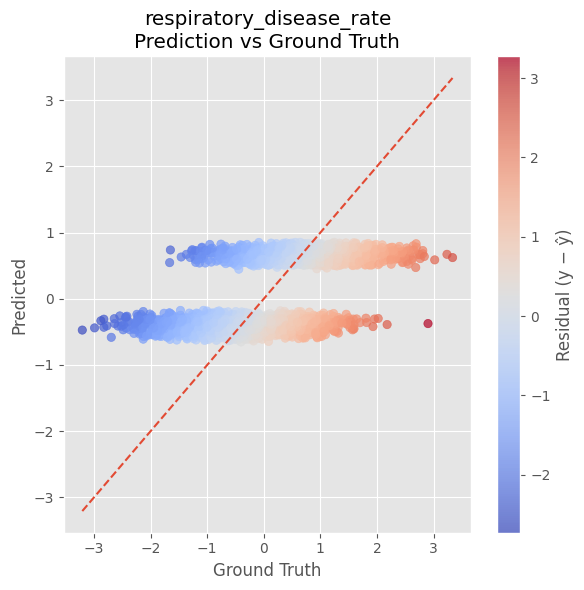

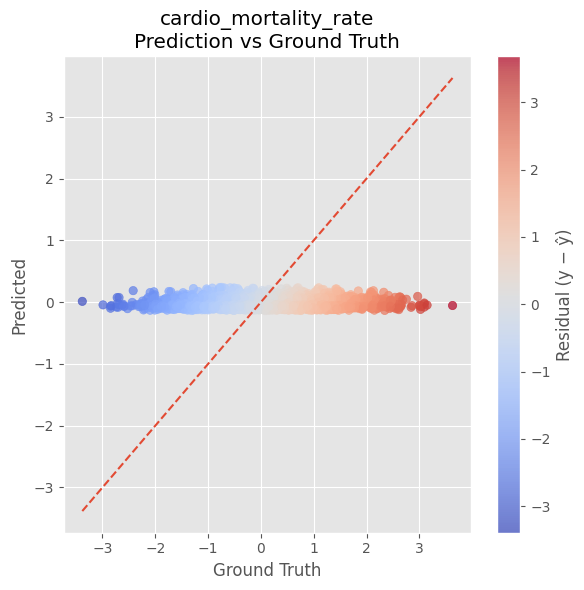

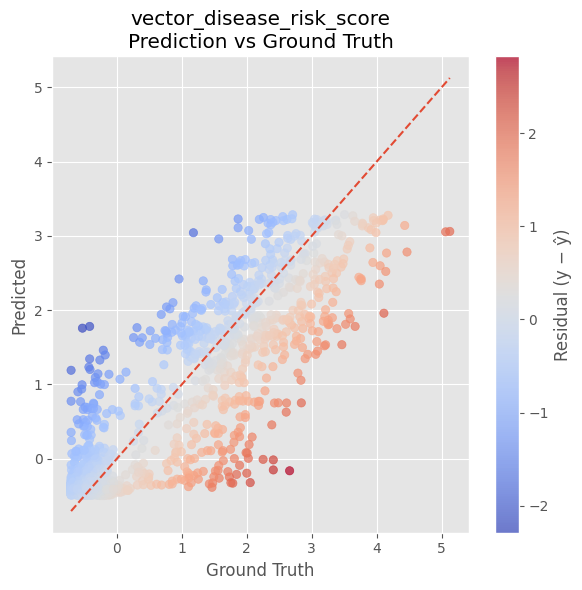

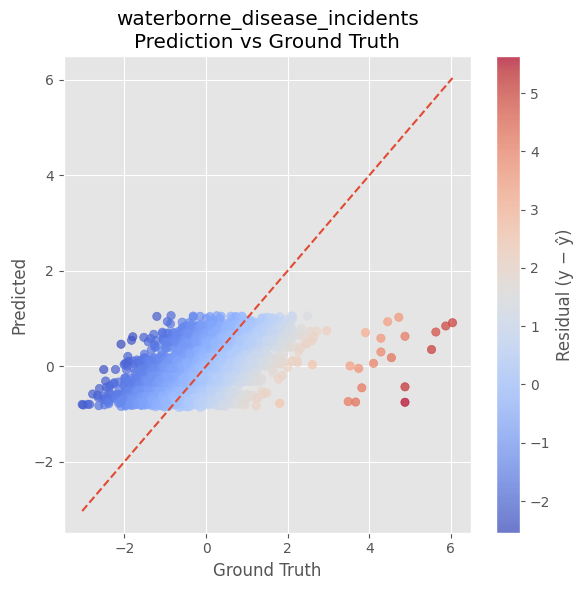

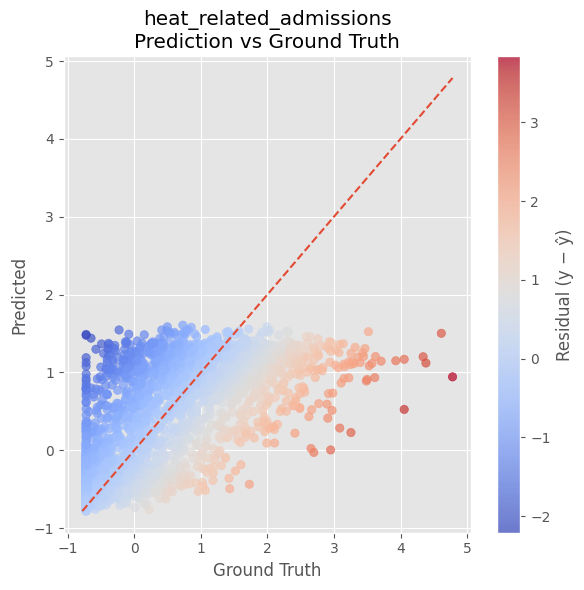

In [ ]:
for i, target in enumerate(targets):
    plt.figure(figsize=(6, 6))

    sc = plt.scatter(
        y_true[:, i],
        y_pred[:, i],
        c=residuals[:, i],
        cmap="coolwarm",
        alpha=0.7
    )

    min_val = min(y_true[:, i].min(), y_pred[:, i].min())
    max_val = max(y_true[:, i].max(), y_pred[:, i].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("Ground Truth")
    plt.ylabel("Predicted")
    plt.title(f"{target}\nPrediction vs Ground Truth")

    plt.colorbar(sc, label="Residual (y − ŷ)")
    plt.tight_layout()
    plt.show()


> *Prediction VS observation scatter plots were used to visually assess model calibration and error dispersion for each health indicator independently. The diagonal line represents perfect prediction.*

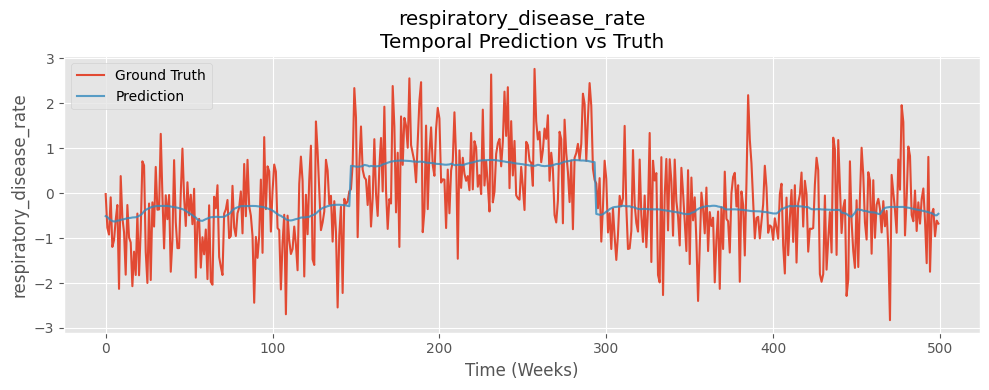

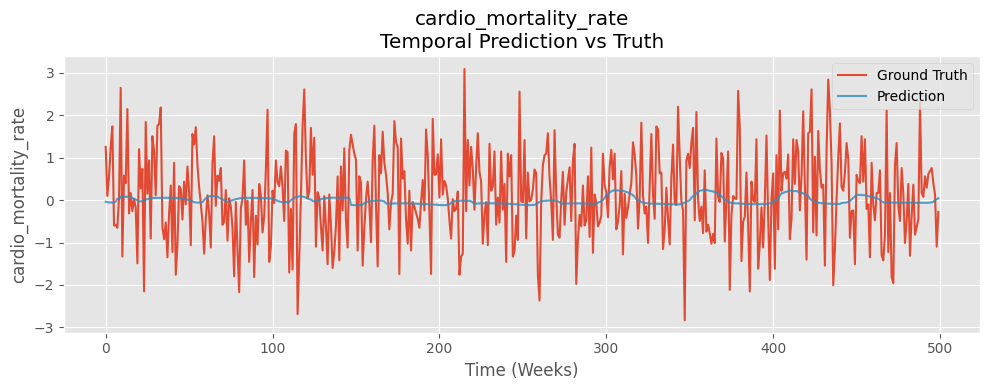

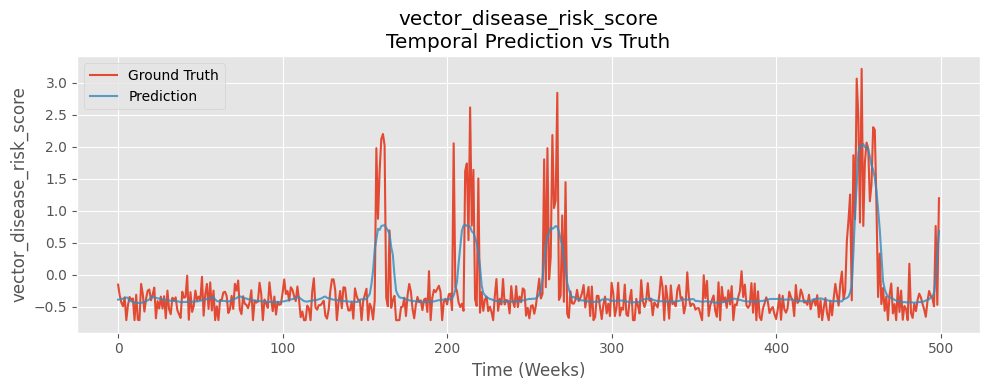

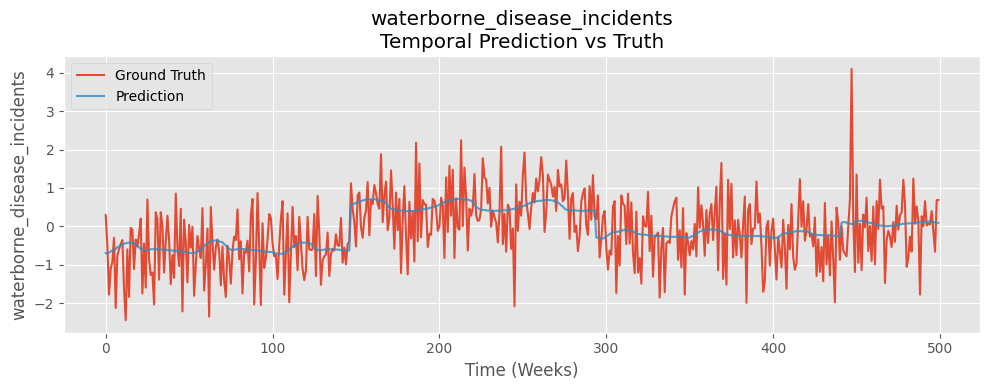

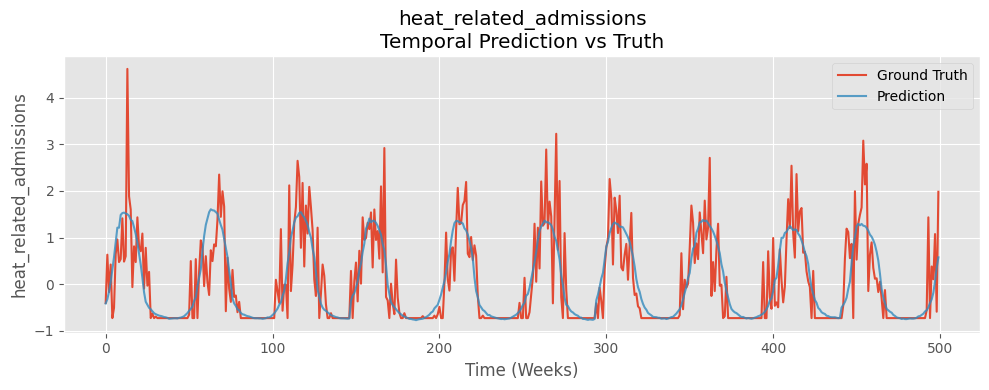

In [ ]:
for i, target in enumerate(targets):

    plt.figure(figsize=(10, 4))

    plt.plot(y_true[:500, i], label="Ground Truth")
    plt.plot(y_pred[:500, i], label="Prediction", alpha=0.8)

    plt.xlabel("Time (Weeks)")
    plt.ylabel(target)
    plt.title(f"{target}\nTemporal Prediction vs Truth")
    plt.legend()

    plt.tight_layout()
    plt.show()



> *Residual-based visual diagnostics were used to assess model calibration, temporal consistency, and performance under extreme health events. Error dispersion increased during high-magnitude outcomes, highlighting the intrinsic difficulty of forecasting rare public-health spikes.*



### Inference